# 16 — Stärke-Bucket-Auswertung: Top-40-Frauen im 2400+-Fenster

Aufbau auf Notebook 14/15: Top-40-Frauen nach Jahresend-Elo (`published_rating`, Dezember 2016–2025), gefiltert auf aktuell **aktive** Spielerinnen → 47 Spielerinnen. Pro Spielerin wird zusätzlich ihr **Schwellenjahr** bestimmt — das erste Jahr, in dem ihre Dezember-Elo ≥ 2400 lag — und nur Partien **ab diesem Jahr bis 2025** (permanent, auch bei späteren Rückgängen unter 2400) fließen in die Analyse ein.

Jede Partie wird nach **Gegnerstärke zum Zeitpunkt der Partie** in drei Gruppen eingeteilt (`diff = opponent_rating − own_rating`, `own_rating` = `std_rating` aus `rating_history` zur jeweiligen Periode — bewusst ein anderes Rating-Konzept als die `published_rating`-Jahresendwerte, die die Kohorte/Schwelle definieren):

- **schwächer**: `diff < -50`
- **gleich stark**: `-50 <= diff <= 50` (beide Grenzen inklusive)
- **stärker**: `diff > 50`

Dazu ein vierter Bucket **Gesamt**, der die drei Stärke-Gruppen zu einer Zeile zusammenfasst (alle Partien, unabhängig vom Stärkeverhältnis).

Jede Gruppe wird zusätzlich nach Gegner-Geschlecht aufgeschlüsselt (Gesamt/vs. Frauen/vs. Männer). Kennzahlen: Sieg/Remis/Niederlage, Punktequote, Ø-Gegner-Elo, Ø-Elo-Änderung (`rating_change_weighted`), Anzahl Partien.

**Datenarchitektur:** ein einziger Partien-Faktentensor (`games`) trägt alle nötigen Spalten (`name`, `year`, `strength_bucket`, `opponent_sex`); eine generische `summarize()`/`build_table()`-Kombination erzeugt daraus je nach übergebenen Gruppierungsspalten alle Tabellen unten — keine Sonderfälle pro Auswertungsebene, auch der `Gesamt`-Bucket entsteht per Rollup statt als Extra-Codepfad. Der Datenwürfel je Spielerin × Jahr ist zu groß für sinnvolle Inline-Anzeige und wird nur exportiert (spätere Basis für eine interaktive Drilldown-Ansicht).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from _setup import load_query, apply_style

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

apply_style()
pd.set_option('display.max_rows', 500)

## Kohorte + Schwellenjahr laden

Eine Query liefert für jede Spielerin, die je in einem Top-40-Jahresende stand, ihre komplette Jahresend-Historie 2016–2025 (Rang + Rating) — daraus werden in Pandas `year_added` (erstes Top-40-Jahr) und `threshold_year` (erstes Jahr mit `published_rating >= 2400`) abgeleitet und auf `active = TRUE` gefiltert.

In [2]:
sql_roster = '''
WITH female_years AS (
    SELECT rh.fide_id, p.name, p.active, rh.period, rh.published_rating,
           ROW_NUMBER() OVER (PARTITION BY rh.period ORDER BY rh.published_rating DESC) AS rnk
    FROM rating_history rh
    JOIN players p ON p.fide_id = rh.fide_id
    WHERE p.sex = 'F'
      AND rh.published_rating IS NOT NULL
      AND rh.period IN ('2016-12-01','2017-12-01','2018-12-01','2019-12-01','2020-12-01',
                        '2021-12-01','2022-12-01','2023-12-01','2024-12-01','2025-12-01')
),
top40_ids AS (
    SELECT DISTINCT fide_id FROM female_years WHERE rnk <= 40
)
SELECT fy.fide_id, fy.name, fy.active, fy.period, fy.published_rating, fy.rnk
FROM female_years fy
JOIN top40_ids t ON t.fide_id = fy.fide_id
'''
raw = load_query(sql_roster)
raw['year'] = pd.to_datetime(raw['period']).dt.year
raw_active = raw[raw['active']].copy()

year_added = raw_active[raw_active['rnk'] <= 40].groupby('fide_id')['year'].min().rename('year_added')
threshold_year = raw_active[raw_active['published_rating'] >= 2400].groupby('fide_id')['year'].min().rename('threshold_year')
names = raw_active.drop_duplicates('fide_id').set_index('fide_id')['name']

roster = pd.concat([names, year_added, threshold_year], axis=1).reset_index()
assert roster['threshold_year'].notna().all(), 'Spielerin ohne Schwellenjahr gefunden'
roster['year_added'] = roster['year_added'].astype(int)
roster['threshold_year'] = roster['threshold_year'].astype(int)
roster = roster.sort_values('name').reset_index(drop=True)

print(f'Kohorte: {len(roster)} Spielerinnen')
print('Schwellenjahr-Verteilung:')
print(roster['threshold_year'].value_counts().sort_index())

Kohorte: 47 Spielerinnen
Schwellenjahr-Verteilung:
threshold_year
2016    33
2017     1
2018     4
2019     2
2021     4
2022     1
2023     1
2025     1
Name: count, dtype: int64


## Partien-Fakten-Tabelle laden

Pro Spielerin nur Partien ab ihrem individuellen Schwellenjahr (`VALUES`-Liste aus `roster`, ein Fenster pro Spielerin statt eines einzigen globalen Zeitraums). `own_rating` wie in Notebook 13–15 per `LEFT JOIN rating_history` auf `std_rating` (Rating zum Partie-Zeitpunkt, nicht der Jahresend-Snapshot).

In [3]:
values_rows = ',\n    '.join(
    f"({int(fid)}, DATE '{int(ty)}-01-01')"
    for fid, ty in zip(roster['fide_id'], roster['threshold_year'])
)
sql_games = f'''
WITH windows(fide_id, start_date) AS (
    VALUES
    {values_rows}
)
SELECT gr.fide_id, gr.period, gr.opponent_rating, gr.opponent_sex,
       gr.result, gr.rating_change_weighted, rh.std_rating AS own_rating
FROM game_results gr
JOIN windows w             ON w.fide_id = gr.fide_id
LEFT JOIN rating_history rh ON rh.fide_id = gr.fide_id AND rh.period = gr.period
WHERE gr.period >= w.start_date AND gr.period <= '2025-12-31'
'''
games_raw = load_query(sql_games)
games_raw = games_raw.merge(roster[['fide_id', 'name']], on='fide_id', how='left')

games_raw['result'] = games_raw['result'].astype(float)
games_raw['rating_change_weighted'] = games_raw['rating_change_weighted'].astype(float)
games_raw['own_rating'] = pd.to_numeric(games_raw['own_rating'], errors='coerce')
games_raw['opponent_rating'] = pd.to_numeric(games_raw['opponent_rating'], errors='coerce')
games_raw['year'] = pd.to_datetime(games_raw['period']).dt.year

n_raw = len(games_raw)
games = games_raw.dropna(subset=['own_rating', 'opponent_rating']).copy()
print(f'{n_raw:,} Partien geladen, {n_raw - len(games):,} ohne own_rating/opponent_rating verworfen '
      f'({(n_raw - len(games)) / n_raw:.1%}) -> {len(games):,} Partien in der Analyse')
print(f'Eindeutige Spielerinnen mit Partien: {games["fide_id"].nunique()}')

games['diff'] = games['opponent_rating'] - games['own_rating']

def strength_bucket(d):
    if pd.isna(d):
        return 'unknown'
    if d > 50:
        return 'stärker'
    if d < -50:
        return 'schwächer'
    return 'gleich'
games['strength_bucket'] = games['diff'].apply(strength_bucket)

BUCKET_ORDER = ['schwächer', 'gleich', 'stärker']
BUCKET_ORDER_FULL = BUCKET_ORDER + ['Gesamt']
SEX_GROUP_ORDER = ['Gesamt', 'F', 'M']
N_COLS = ['n_partien', 'siege', 'remis', 'niederlagen']
games['strength_bucket'].value_counts().reindex(BUCKET_ORDER)

22,596 Partien geladen, 0 ohne own_rating/opponent_rating verworfen (0.0%) -> 22,596 Partien in der Analyse
Eindeutige Spielerinnen mit Partien: 47


strength_bucket
schwächer    13533
gleich        5285
stärker       3778
Name: count, dtype: int64

## 1. Partien pro Jahr × Spielerin

In [4]:
year_pivot = games.groupby(['name', 'year']).size().unstack(fill_value=0)
for y in range(2016, 2026):
    if y not in year_pivot.columns:
        year_pivot[y] = 0
year_pivot = year_pivot[sorted(year_pivot.columns)]
year_pivot['Gesamt'] = year_pivot.sum(axis=1)
year_pivot = year_pivot.sort_values('Gesamt', ascending=False)
year_pivot

year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Gesamt
name,,,,,,,,,,,
"Socko, Monika",107,94,106,86,62,86,85,96,100,81,903
"Batsiashvili, Nino",96,100,76,87,58,64,108,80,69,71,809
"Daulyte-Cornette, Deimante",123,109,107,82,0,46,66,58,80,96,767
"Paehtz, Elisabeth",118,100,88,89,42,65,45,65,51,48,711
"Goryachkina, Aleksandra",104,72,98,93,52,76,26,79,41,55,696
"Shuvalova, Polina",0,0,96,96,59,80,68,79,106,87,671
"Cramling, Pia",98,81,86,123,43,46,62,50,58,23,670
"Tsolakidou, Stavroula",0,87,79,82,24,50,75,93,94,74,658
"Atalik, Ekaterina",85,90,69,79,35,56,64,49,51,57,635


## 2. Kennzahlen-Helfer

`summarize()` liefert für eine beliebige Partien-Teilmenge Sieg/Remis/Niederlage, Punktequote, Ø-Gegner-Elo und Ø-Elo-Änderung. `with_bucket_rollup()` verdoppelt den DataFrame um eine zusätzliche `strength_bucket == 'Gesamt'`-Kopie (Summe über schwächer/gleich/stärker); `with_sex_rollup()` verdreifacht zusätzlich nach Gegner-Geschlecht (Gesamt/vs. F/vs. M als Spalte `sex_group`). Beide zusammen liefern in einem einzigen `groupby` sowohl die volle Stärke- als auch die Geschlechts-Aufschlüsselung inkl. Gesamtzeilen. `build_table()` gruppiert nach beliebigen Spalten — dieselbe Funktion erzeugt alle Tabellen unten, nur mit anderen Gruppierungsspalten.

In [5]:
def summarize(sub):
    n = len(sub)
    if n == 0:
        return pd.Series({
            'n_partien': 0, 'siege': 0, 'remis': 0, 'niederlagen': 0,
            'punktequote': np.nan, 'avg_opponent_rating': np.nan, 'mean_delta': np.nan,
        })
    return pd.Series({
        'n_partien': n,
        'siege': (sub['result'] == 1).sum(),
        'remis': (sub['result'] == 0.5).sum(),
        'niederlagen': (sub['result'] == 0).sum(),
        'punktequote': sub['result'].mean(),
        'avg_opponent_rating': sub['opponent_rating'].mean(),
        'mean_delta': sub['rating_change_weighted'].mean(),
    })

def with_sex_rollup(df_scope):
    return pd.concat([
        df_scope.assign(sex_group='Gesamt'),
        df_scope[df_scope.opponent_sex == 'F'].assign(sex_group='F'),
        df_scope[df_scope.opponent_sex == 'M'].assign(sex_group='M'),
    ], ignore_index=True)

def with_bucket_rollup(df_scope):
    return pd.concat([
        df_scope,
        df_scope.assign(strength_bucket='Gesamt'),
    ], ignore_index=True)

def build_table(df_scope, group_cols):
    return df_scope.groupby(group_cols).apply(summarize, include_groups=False).reset_index()

games_full = with_sex_rollup(with_bucket_rollup(games))
print(f'games_full: {len(games_full):,} Zeilen (Original × 4 Stärke-Buckets [inkl. Gesamt] × Gesamt/F/M-Rollup)')

games_full: 89,642 Zeilen (Original × 4 Stärke-Buckets [inkl. Gesamt] × Gesamt/F/M-Rollup)


## 3. Gesamtzeitraum — pro Spielerin × Bucket × Geschlecht

Vollständiges Raster (47 Spielerinnen × 4 Buckets [schwächer/gleich/stärker + **Gesamt** als Summe der drei] × 3 Geschlechts-Gruppen = 564 Zeilen); Kombinationen ohne Partien erscheinen mit 0.

In [6]:
full_index_overall_player = pd.MultiIndex.from_product(
    [roster['name'], BUCKET_ORDER_FULL, SEX_GROUP_ORDER],
    names=['name', 'strength_bucket', 'sex_group'],
)
table_overall = (
    build_table(games_full, ['name', 'strength_bucket', 'sex_group'])
    .set_index(['name', 'strength_bucket', 'sex_group'])
    .reindex(full_index_overall_player)
)
table_overall[N_COLS] = table_overall[N_COLS].fillna(0).astype(int)
table_overall = table_overall.reset_index()
table_overall.round(3)

,name,strength_bucket,sex_group,n_partien,siege,remis,niederlagen,punktequote,avg_opponent_rating,mean_delta
0,"Arabidze, Meri",schwächer,Gesamt,200,117,62,21,0.740,2223.435,-0.042
1,"Arabidze, Meri",schwächer,F,190,111,60,19,0.742,2226.984,0.009
2,"Arabidze, Meri",schwächer,M,10,6,2,2,0.700,2156.000,-1.010
3,"Arabidze, Meri",gleich,Gesamt,74,21,37,16,0.534,2423.595,0.241
4,"Arabidze, Meri",gleich,F,60,16,30,14,0.517,2420.483,0.033
...,...,...,...,...,...,...,...,...,...,...
559,"Zhu, Jiner",stärker,F,42,10,23,9,0.512,2511.238,2.650
560,"Zhu, Jiner",stärker,M,73,12,32,29,0.384,2586.370,0.552
561,"Zhu, Jiner",Gesamt,Gesamt,464,211,163,90,0.630,2383.103,0.540
562,"Zhu, Jiner",Gesamt,F,293,145,106,42,0.676,2362.512,0.803


## 4. Gesamtzeitraum — aggregiert über alle 47 Spielerinnen

Die "Executive Summary"-Tabelle: 4 Buckets (schwächer/gleich/stärker + **Gesamt** als Summe der drei Stärke-Gruppen) × 3 Geschlechts-Gruppen = 12 Zeilen. Die `Gesamt`-Bucket-Zeilen beantworten dabei auch die stärke-unabhängige Frage "schneiden die Top-40-Frauen gegen Männer anders ab als gegen Frauen, über alle Partien hinweg?" — eine separate Tabelle ohne Stärke-Split ist dafür nicht mehr nötig.

In [7]:
full_index_overall = pd.MultiIndex.from_product(
    [BUCKET_ORDER_FULL, SEX_GROUP_ORDER], names=['strength_bucket', 'sex_group']
)
agg_overall = (
    build_table(games_full, ['strength_bucket', 'sex_group'])
    .set_index(['strength_bucket', 'sex_group'])
    .reindex(full_index_overall)
)
agg_overall[N_COLS] = agg_overall[N_COLS].fillna(0).astype(int)
agg_overall = agg_overall.reset_index()
agg_overall.round(4)

,strength_bucket,sex_group,n_partien,siege,remis,niederlagen,punktequote,avg_opponent_rating,mean_delta
0,schwächer,Gesamt,13533,7341,4694,1498,0.7159,2271.8302,-0.1794
1,schwächer,F,10290,5439,3720,1131,0.7093,2277.8168,-0.2099
2,schwächer,M,2936,1712,896,328,0.7357,2253.6574,-0.0947
3,gleich,Gesamt,5285,1337,2810,1138,0.5188,2465.7913,0.1550
4,gleich,F,4402,1116,2362,924,0.5218,2466.0479,0.1722
5,gleich,M,834,206,427,201,0.5030,2467.6739,0.0785
6,stärker,Gesamt,3778,527,1773,1478,0.3741,2570.6294,0.3626
7,stärker,F,1476,235,766,475,0.4187,2524.8828,0.4491
8,stärker,M,2287,291,1000,996,0.3459,2600.5120,0.3114
9,Gesamt,Gesamt,22596,9205,9277,4114,0.6127,2367.1545,-0.0106


## 5. Chart — Punktequote je Bucket × Gegner-Geschlecht (Gesamtzeitraum)

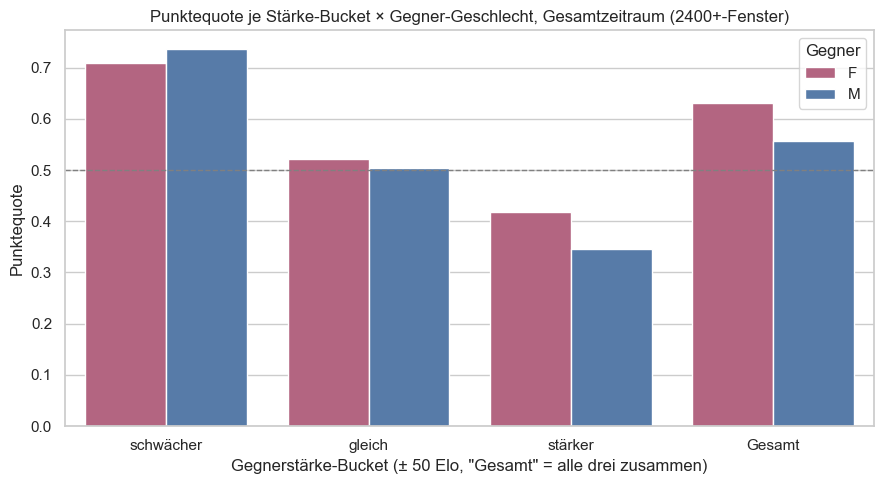

In [8]:
plot_data = agg_overall[agg_overall.sex_group.isin(['F', 'M'])]
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=plot_data, x='strength_bucket', order=BUCKET_ORDER_FULL,
    y='punktequote', hue='sex_group', hue_order=['F', 'M'],
    palette={'F': '#c0587e', 'M': '#4a7ab5'}, ax=ax,
)
ax.axhline(0.5, color='grey', lw=1, ls='--')
ax.set_xlabel('Gegnerstärke-Bucket (± 50 Elo, "Gesamt" = alle drei zusammen)')
ax.set_ylabel('Punktequote')
ax.set_title('Punktequote je Stärke-Bucket × Gegner-Geschlecht, Gesamtzeitraum (2400+-Fenster)')
ax.legend(title='Gegner')
plt.tight_layout(); plt.show()

## 6. Pro Jahr — aggregiert über alle Spielerinnen

In [9]:
years_present = sorted(games['year'].unique())
full_index_year = pd.MultiIndex.from_product(
    [years_present, BUCKET_ORDER_FULL, SEX_GROUP_ORDER],
    names=['year', 'strength_bucket', 'sex_group'],
)
agg_by_year = (
    build_table(games_full, ['year', 'strength_bucket', 'sex_group'])
    .set_index(['year', 'strength_bucket', 'sex_group'])
    .reindex(full_index_year)
)
agg_by_year[N_COLS] = agg_by_year[N_COLS].fillna(0).astype(int)
agg_by_year = agg_by_year.reset_index()
agg_by_year.round(4)

,year,strength_bucket,sex_group,n_partien,siege,remis,niederlagen,punktequote,avg_opponent_rating,mean_delta
0,2016,schwächer,Gesamt,1505,843,489,173,0.7226,2295.3588,-0.1445
1,2016,schwächer,F,1075,577,374,124,0.7107,2297.5470,-0.2588
2,2016,schwächer,M,371,227,100,44,0.7466,2291.9407,0.0574
3,2016,gleich,Gesamt,547,139,285,123,0.5146,2489.9872,0.0963
4,2016,gleich,F,440,116,229,95,0.5239,2486.7750,0.1784
5,2016,gleich,M,101,20,53,28,0.4604,2507.9802,-0.3861
6,2016,stärker,Gesamt,489,65,228,196,0.3661,2605.3333,0.2442
7,2016,stärker,F,168,30,86,52,0.4345,2553.3750,0.5262
8,2016,stärker,M,320,35,142,143,0.3312,2632.7750,0.1059
9,2016,Gesamt,Gesamt,2541,1047,1002,492,0.6092,2396.9091,-0.0178


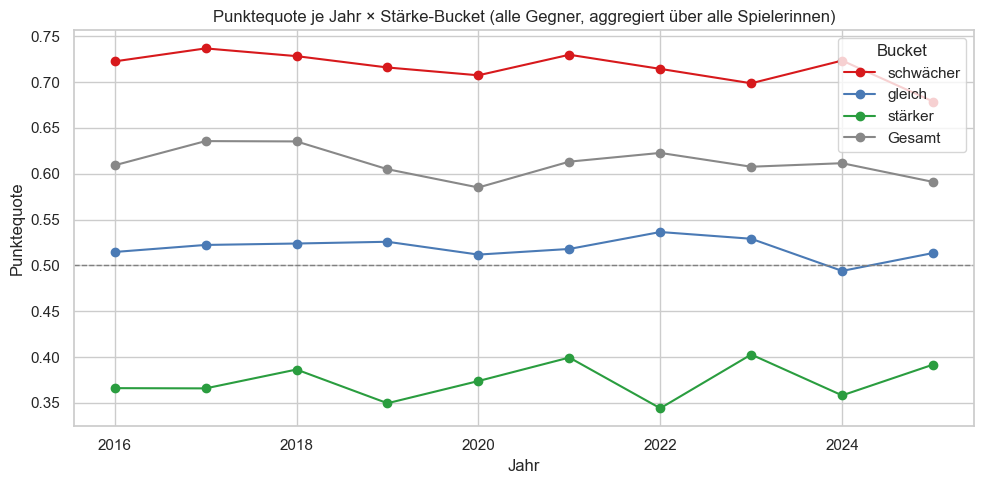

In [10]:
plot_year = agg_by_year[agg_by_year.sex_group == 'Gesamt']
fig, ax = plt.subplots(figsize=(10, 5))
for bucket, color in zip(BUCKET_ORDER_FULL, ['#d7191c', '#4a7ab5', '#2a9d3f', '#888888']):
    sub = plot_year[plot_year.strength_bucket == bucket]
    ax.plot(sub['year'], sub['punktequote'], marker='o', label=bucket, color=color)
ax.axhline(0.5, color='grey', lw=1, ls='--')
ax.set_xlabel('Jahr')
ax.set_ylabel('Punktequote')
ax.set_title('Punktequote je Jahr × Stärke-Bucket (alle Gegner, aggregiert über alle Spielerinnen)')
ax.legend(title='Bucket')
plt.tight_layout(); plt.show()

## 7. Pro Jahr × Spielerin (Datenwürfel, nur Export)

Bis zu 47 × 10 × 4 × 3 = 5.640 Zeilen — nicht sinnvoll inline darstellbar. Anders als Tabelle 3 wird hier **nicht** auf ein volles Raster reindexiert: Jahre vor dem individuellen Schwellenjahr einer Spielerin fehlen zu Recht (sie waren dort noch nicht im 2400+-Fenster), eine erzwungene 0-Zeile wäre irreführend. Diese Tabelle ist die vorgesehene Datenbasis für eine spätere interaktive Drilldown-Ansicht.

In [11]:
table_by_year = build_table(games_full, ['name', 'year', 'strength_bucket', 'sex_group'])
table_by_year[N_COLS] = table_by_year[N_COLS].astype(int)
table_by_year['strength_bucket'] = pd.Categorical(table_by_year['strength_bucket'], BUCKET_ORDER_FULL, ordered=True)
table_by_year['sex_group'] = pd.Categorical(table_by_year['sex_group'], SEX_GROUP_ORDER, ordered=True)
table_by_year = table_by_year.sort_values(['name', 'year', 'strength_bucket', 'sex_group']).reset_index(drop=True)
print(f'{len(table_by_year):,} Zeilen im vollen Datenwürfel — Beispiel für eine Spielerin:')

demo_name = roster.loc[roster['threshold_year'] == roster['threshold_year'].min(), 'name'].iloc[0]
table_by_year[table_by_year.name == demo_name].round(3)

4,030 Zeilen im vollen Datenwürfel — Beispiel für eine Spielerin:


,name,year,strength_bucket,sex_group,n_partien,siege,remis,niederlagen,punktequote,avg_opponent_rating,mean_delta
122,"Atalik, Ekaterina",2016,schwächer,Gesamt,50,35,9,6,0.790,2179.600,0.232
123,"Atalik, Ekaterina",2016,schwächer,F,31,22,6,3,0.806,2195.871,0.545
124,"Atalik, Ekaterina",2016,schwächer,M,14,12,0,2,0.857,2132.214,0.486
125,"Atalik, Ekaterina",2016,gleich,Gesamt,14,2,9,3,0.464,2423.571,-0.250
126,"Atalik, Ekaterina",2016,gleich,F,11,1,7,3,0.409,2427.000,-0.791
127,"Atalik, Ekaterina",2016,gleich,M,2,1,1,0,0.750,2411.500,2.700
128,"Atalik, Ekaterina",2016,stärker,Gesamt,21,7,9,5,0.548,2514.381,1.929
129,"Atalik, Ekaterina",2016,stärker,F,7,1,4,2,0.429,2495.143,0.443
130,"Atalik, Ekaterina",2016,stärker,M,14,6,5,3,0.607,2524.000,2.671
131,"Atalik, Ekaterina",2016,Gesamt,Gesamt,85,44,27,14,0.676,2302.494,0.572


## 8. Signifikanztest — gleich starke Gegner, Frauen vs. Männer (Spieler-Ebene)

Die Rohtabelle (Abschnitt 4) zeigt im "gleich stark"-Bucket eine Punktequote von 0,522 gegen Frauen vs. 0,503 gegen Männer — beide über 50&nbsp;%, aber ist der *Unterschied* zwischen beiden mehr als Stichprobenrauschen? Partien sind nicht unabhängig (manche Spielerinnen liefern viele Partien in dieser Zelle, andere kaum welche), daher wie in Notebook 14 ein **Permutationstest auf Spieler-Ebene** (Ø Punktequote pro `fide_id`, nicht pro Partie): 10.000 Permutationen, fester Seed, kein scipy/statsmodels nötig.

In [12]:
def permutation_test(a, b, n_perm=10000, seed=42, return_diffs=False):
    rng = np.random.default_rng(seed)
    observed = a.mean() - b.mean()
    pooled = np.concatenate([a, b])
    n_a = len(a)
    diffs = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(pooled)
        diffs[i] = pooled[:n_a].mean() - pooled[n_a:].mean()
    p_value = (np.abs(diffs) >= np.abs(observed)).mean()
    return (observed, p_value, diffs) if return_diffs else (observed, p_value)

gleich = games[games.strength_bucket == 'gleich']
pm_f = gleich[gleich.opponent_sex == 'F'].groupby('fide_id')['result'].mean()
pm_m = gleich[gleich.opponent_sex == 'M'].groupby('fide_id')['result'].mean()
a, b = pm_f.values, pm_m.values
observed, p_value, diffs = permutation_test(a, b, return_diffs=True)

print(f'Spielerinnen mit Partien vs. Frauen (gleich stark): {len(a)}')
print(f'Spielerinnen mit Partien vs. Männer (gleich stark): {len(b)}')
print(f'Ø Punktequote vs. Frauen (Spieler-Mittel): {a.mean():.4f}')
print(f'Ø Punktequote vs. Männer (Spieler-Mittel): {b.mean():.4f}')
print(f'Beobachtete Differenz (Frauen \u2212 Männer): {observed:+.4f}')
print(f'Permutations-p-Wert (10.000 Permutationen, zweiseitig): {p_value:.4f}')
if min(len(a), len(b)) < 8:
    print('Achtung: underpowered (< 8 Spielerinnen in einer Gruppe)')

Spielerinnen mit Partien vs. Frauen (gleich stark): 46
Spielerinnen mit Partien vs. Männer (gleich stark): 44
Ø Punktequote vs. Frauen (Spieler-Mittel): 0.5300
Ø Punktequote vs. Männer (Spieler-Mittel): 0.4845
Beobachtete Differenz (Frauen − Männer): +0.0454
Permutations-p-Wert (10.000 Permutationen, zweiseitig): 0.0319


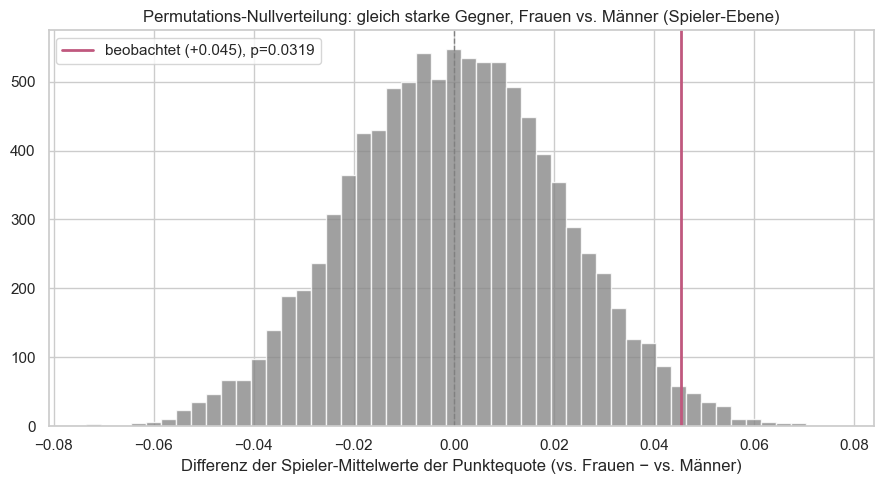

In [13]:
fig, ax = plt.subplots()
ax.hist(diffs, bins=50, color='#888888', alpha=0.8)
ax.axvline(observed, color='#c0587e', lw=2,
           label=f'beobachtet ({observed:+.3f}), p={p_value:.4f}')
ax.axvline(0, color='grey', lw=1, ls='--')
ax.set_title('Permutations-Nullverteilung: gleich starke Gegner, Frauen vs. Männer (Spieler-Ebene)')
ax.set_xlabel('Differenz der Spieler-Mittelwerte der Punktequote (vs. Frauen \u2212 vs. Männer)')
ax.legend()
plt.tight_layout(); plt.show()

### Robustheits-Check: Mindestanzahl Partien pro Spielerin

Bei `min_n=1` zählt eine Spielerin mit nur 1–4 Partien vs. Männer genauso viel wie eine mit 77 — ihr persönlicher Mittelwert ist dann extrem verrauscht (z.B. 1/6 Punkten bei nur 3 Partien). Sweep über eine Mindest-Partienzahl pro Spielerin prüft, ob der Effekt robust ist oder von genau diesen dünn besetzten Zellen getrieben wird.

In [14]:
pm_f_full = gleich[gleich.opponent_sex == 'F'].groupby('fide_id')['result'].agg(['mean', 'count'])
pm_m_full = gleich[gleich.opponent_sex == 'M'].groupby('fide_id')['result'].agg(['mean', 'count'])

sweep_rows = []
for min_n in [1, 5, 8, 10]:
    a_s = pm_f_full[pm_f_full['count'] >= min_n]['mean'].values
    b_s = pm_m_full[pm_m_full['count'] >= min_n]['mean'].values
    obs_s, p_s = permutation_test(a_s, b_s)
    sweep_rows.append({
        'min_partien_pro_spielerin': min_n, 'n_spielerinnen_f': len(a_s), 'n_spielerinnen_m': len(b_s),
        'mean_f': round(a_s.mean(), 4), 'mean_m': round(b_s.mean(), 4),
        'differenz': round(obs_s, 4), 'p_wert': round(p_s, 4),
    })
pd.DataFrame(sweep_rows)

,min_partien_pro_spielerin,n_spielerinnen_f,n_spielerinnen_m,mean_f,mean_m,differenz,p_wert
0,1,46,44,0.53,0.4845,0.0454,0.0319
1,5,46,38,0.53,0.5084,0.0215,0.2164
2,8,46,36,0.53,0.5052,0.0248,0.1108
3,10,46,33,0.53,0.5092,0.0207,0.1974


## Export

CSVs landen (wie bei Notebook 15) relativ im Ausführungsverzeichnis (`notebooks/`, per `.gitignore` ausgeschlossen). `top40_2400_overall_by_sex.csv` wird direkt aus der `Gesamt`-Bucket-Zeile von Tabelle 4 abgeleitet (kein separater Rechenweg mehr nötig, siehe Abschnitt 4).

In [15]:
agg_overall_no_bucket = (
    agg_overall[agg_overall.strength_bucket == 'Gesamt']
    .drop(columns='strength_bucket')
    .set_index('sex_group')
    .reindex(SEX_GROUP_ORDER)
    .reset_index()
)

year_pivot.to_csv('top40_2400_games_per_year.csv')
table_overall.to_csv('top40_2400_strength_summary_overall_per_player.csv', index=False)
agg_overall.to_csv('top40_2400_strength_summary_overall_aggregate.csv', index=False)
agg_overall_no_bucket.to_csv('top40_2400_overall_by_sex.csv', index=False)
agg_by_year.to_csv('top40_2400_strength_summary_by_year_aggregate.csv', index=False)
table_by_year.to_csv('top40_2400_strength_summary_by_year_per_player.csv', index=False)
print('wrote 6 CSVs: top40_2400_games_per_year.csv, top40_2400_strength_summary_overall_per_player.csv, '
      'top40_2400_strength_summary_overall_aggregate.csv, top40_2400_overall_by_sex.csv, '
      'top40_2400_strength_summary_by_year_aggregate.csv, top40_2400_strength_summary_by_year_per_player.csv')

wrote 6 CSVs: top40_2400_games_per_year.csv, top40_2400_strength_summary_overall_per_player.csv, top40_2400_strength_summary_overall_aggregate.csv, top40_2400_overall_by_sex.csv, top40_2400_strength_summary_by_year_aggregate.csv, top40_2400_strength_summary_by_year_per_player.csv


## Fazit

Tabelle 4 (Abschnitt 4) beantwortet die Kernfrage direkt: schneiden die Top-40-Frauen im 2400+-Fenster gegen gleich starke/stärkere/schwächere Männer anders ab als gegen ebenso eingestufte Frauen? Die zusätzliche `Gesamt`-Bucket-Zeile zeigt denselben Vergleich ohne die Stärke-Differenzierung — nur noch Gesamt/vs. Frauen/vs. Männer über alle Partien hinweg, unabhängig vom relativen Stärkeverhältnis. Tabelle 3 (pro Spielerin) und der Jahres-Export (Abschnitt 7) erlauben das Aufbrechen dieser Frage auf Einzelspieler- bzw. Jahresebene. Der Permutationstest (Abschnitt 8) prüft für die sauberste Vergleichszelle — gleich starke Gegner, wo das Ø-Gegner-Rating gegen Frauen und Männer praktisch identisch ist — ob der kleine Punktequote-Unterschied (0,522 vs. 0,503) über Stichprobenrauschen hinausgeht, oder ob die beiden Gruppen statistisch nicht unterscheidbar sind.

**Caveats:**
- Bucket-Grenzen: `gleich` schließt exakt ±50 Elo ein (wie in Notebook 13/14); `schwächer`/`stärker` beginnen erst echt darüber/darunter; `Gesamt` ist die reine Summe der drei (keine eigene Stärke-Definition).
- `own_rating` = `std_rating` zum Partie-Zeitpunkt — ein anderes Rating-Konzept als die `published_rating`-Jahresendwerte, die Kohorte und Schwellenjahr definieren; beide Konzepte sind bewusst getrennt gehalten.
- Das Schwellenjahr-Fenster ist pro Spielerin unterschiedlich lang (2016–2025 vs. z.B. nur 2025) — Aggregat-Tabellen über alle Spielerinnen sind entsprechend nicht gleichgewichtig über die Karrierephasen verteilt.